In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np

In [2]:
envs = ["atari_battle_zone", "atari_double_dunk", "atari_phoenix", "atari_this_game", "atari_battle_zone", "box2d_lunar_lander", "box2d_continuous_lunar_lander", "box2d_bipedal_walker", "cc_acrobot", "cc_cartpole", "cc_mountain_car", "cc_continuous_mountain_car", "cc_pendulum", "minigrid_door_key", "minigrid_empty_random", "minigrid_four_rooms", "minigrid_unlock", "brax_ant", "brax_halfcheetah", "brax_hopper", "brax_humanoid"]
algos = ["ppo", "dqn", "sac"]

data = []
for env in envs:
    for algo in algos:
        try:
            partial_data = pd.read_csv(f"arlbench_data/256_10/{env}_{algo}.csv")
            partial_data["env_name"] = env
            partial_data["algorithm"] = algo
            data.append(partial_data)
        except FileNotFoundError:
            continue
data = pd.concat(data)

# 1. Tunability

In [4]:
def get_tunability(df, percentile):
    tunabilities = []
    algos = []
    envs = []
    for env in df["env_name"].unique():
        for algo in df["algorithm"].unique():
            subset = df[(df["env_name"]==env) & (df["algorithm"]==algo)]
            threshold = subset["last_performance"].quantile(percentile)
            tunability = subset["last_performance"].max() - threshold
            tunabilities.append(tunability)
            algos.append(algo)
            envs.append(env)
    tunabilities = pd.DataFrame({
        "env_name": envs,
        "algorithm": algos,
        "tunability": tunabilities
    })
    return tunabilities

In [29]:
all_tunabilities_list = []

for percentile in np.arange(0, 21)/20:
    tunabilities = get_tunability(data, percentile)
    tunabilities["percentile"] = percentile
    all_tunabilities_list.append(tunabilities)

all_tunabilities = pd.concat(all_tunabilities_list)

# add domain to the dataframe via domain = (env.split("_")[0])
all_tunabilities["domain"] = all_tunabilities["env_name"].apply(lambda env: env.split("_")[0])


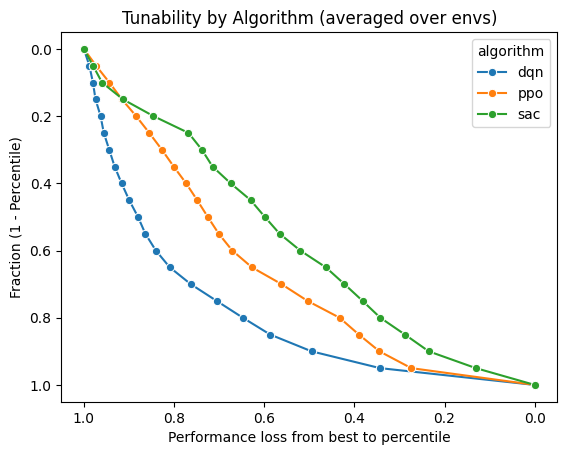

In [30]:
sns.lineplot(
    data=all_tunabilities.groupby(["algorithm", "percentile"])["tunability"].mean().reset_index(),
    y="percentile",
    x="tunability",
    hue="algorithm",
    marker="o"
)
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
plt.ylabel("Fraction (1 - Percentile)")
plt.xlabel("Performance loss from best to percentile")
plt.title("Tunability by Algorithm (averaged over envs)")
plt.show()

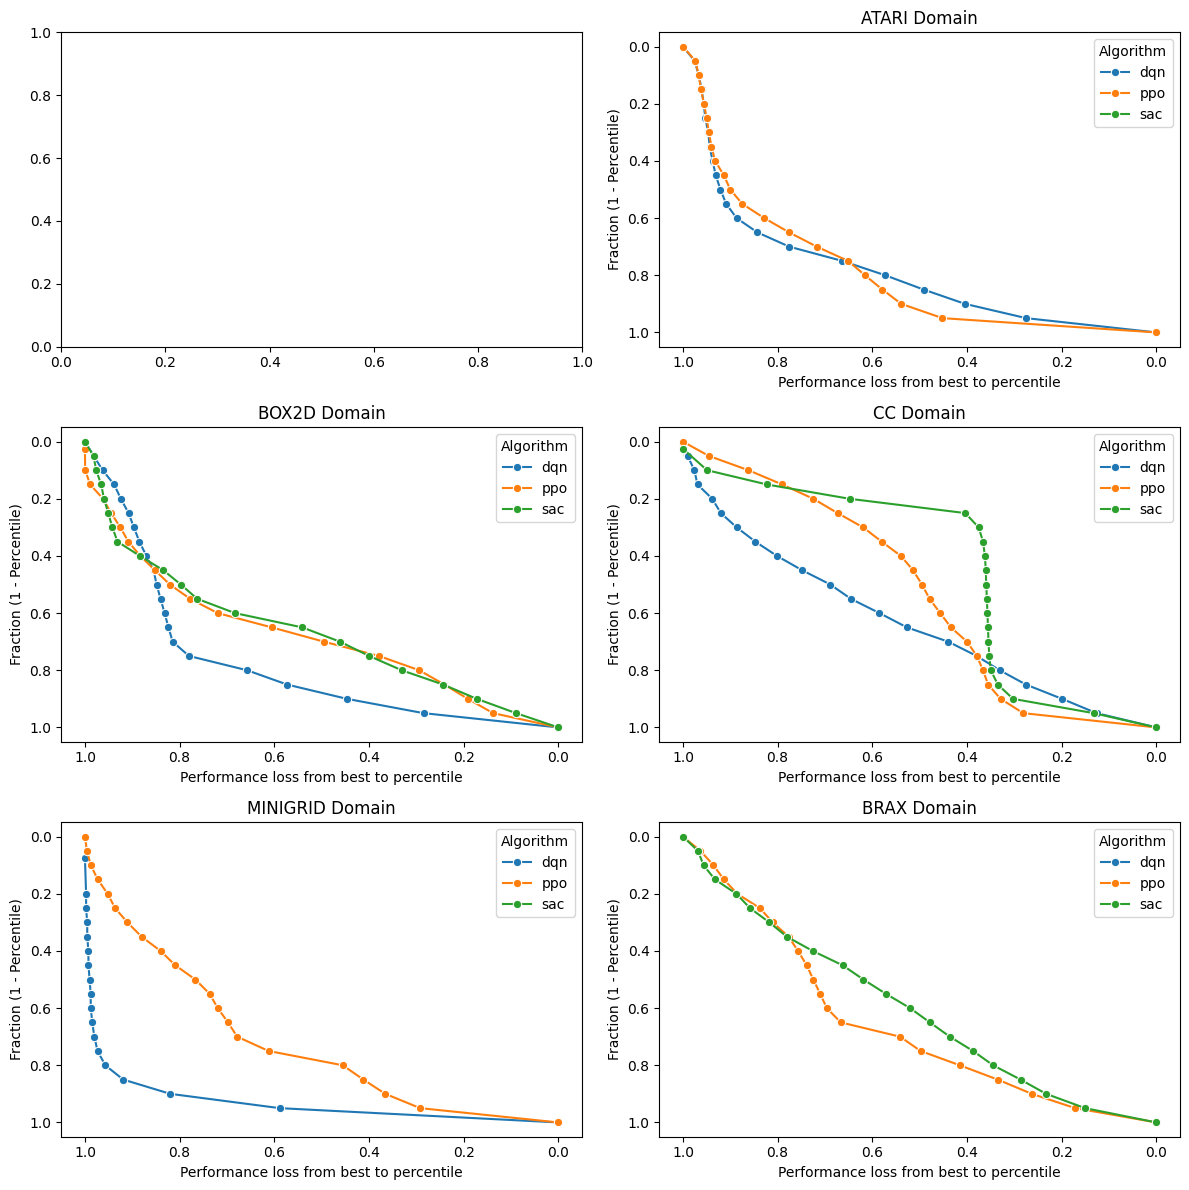

In [33]:
domains = all_tunabilities["domain"].unique()
# Create subplots: 1 for overall + 5 for domains = 6 total, arranged in 3 rows x 2 cols
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

# Plot per domain
for i, domain in enumerate(domains):
    ax = axes[i + 1]
    domain_data = all_tunabilities[all_tunabilities["domain"] == domain]
    
    sns.lineplot(
        data=domain_data.groupby(["algorithm", "percentile"])["tunability"].mean().reset_index(),
        x="tunability",
        y="percentile",
        hue="algorithm",
        marker="o",
        ax=ax
    )
    ax.invert_yaxis()
    ax.invert_xaxis()
    ax.set_ylabel("Fraction (1 - Percentile)")
    ax.set_xlabel("Performance loss from best to percentile")
    ax.set_title(f"{domain.upper()} Domain")
    ax.legend(title="Algorithm")

plt.tight_layout()
plt.show()

# 2. Adkins Hyperparameter sensitivty

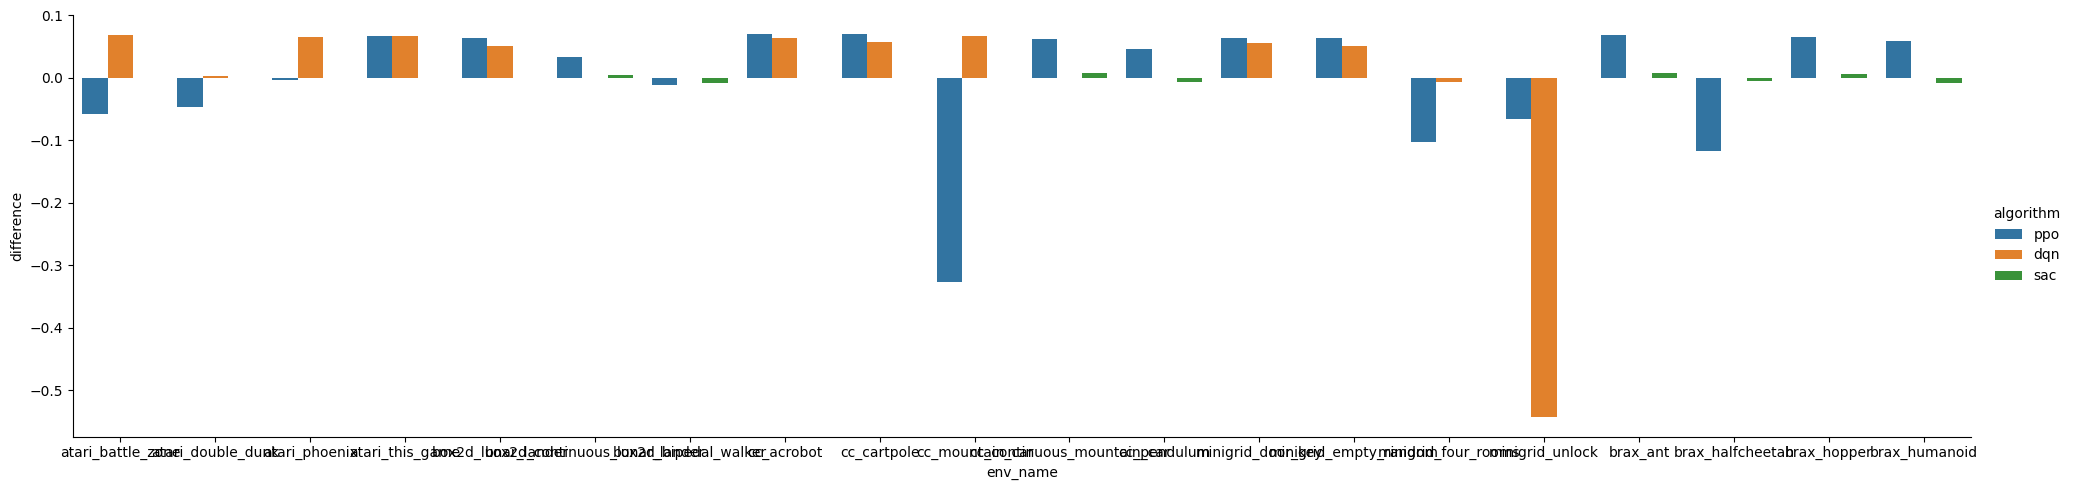

In [34]:
per_env_vs_cross_env_max = []
for algo in algos:
    for env in envs:
        subset = data[data["algorithm"]==algo]
        percentile05 = subset["last_performance"].quantile(0.05)
        percentile95 = subset["last_performance"].quantile(0.95)
        subset = subset[(subset["last_performance"]>=percentile05) & (subset["last_performance"]<=percentile95)]
        cross_env_max = subset.groupby("env_name")["last_performance"].max().mean()
        env_subset = subset[subset["env_name"]==env]
        env_max = env_subset["last_performance"].max()
        difference = env_max - cross_env_max
        per_env_vs_cross_env_max.append({
            "algorithm": algo,
            "env_name": env,
            "env_max": env_max,
            "cross_env_max": cross_env_max,
            "difference": difference
        })
per_env_vs_cross_env_max = pd.DataFrame(per_env_vs_cross_env_max)
sns.catplot(data=per_env_vs_cross_env_max, x="env_name", y="difference", hue="algorithm", kind="bar", aspect=4)

# 3. Rank consistency

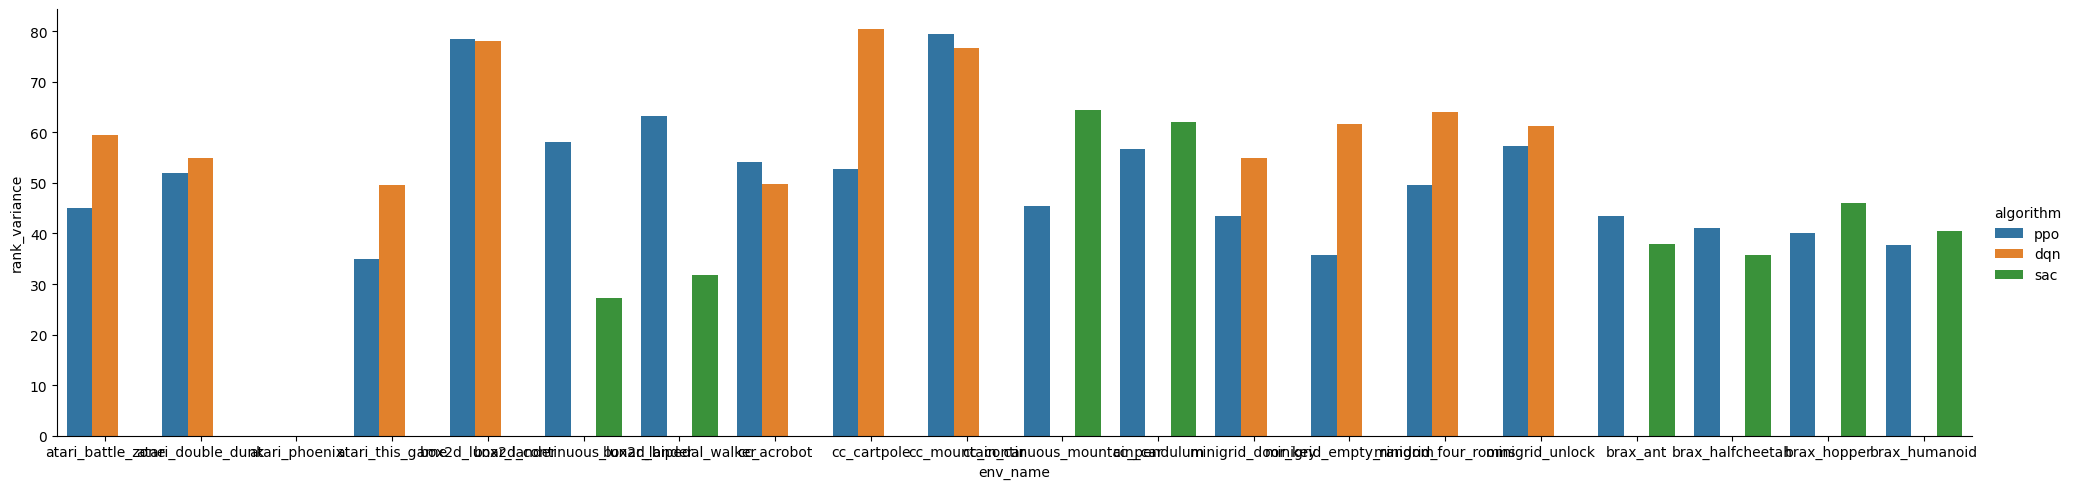

In [39]:
# rank consistency analysis
rank_consistency = []
for env in envs:
    for algo in algos:
        subset = data[data["algorithm"]==algo]
        overall_ranked = subset.groupby("config_id")["last_performance"].mean()
        env_subset = subset[subset["env_name"]==env]
        env_subset = env_subset.groupby("config_id")["last_performance"].mean()
        overall_ranked["rank"] = overall_ranked.rank(ascending=False)
        env_subset["rank"] = env_subset.rank(ascending=False)
        rank_diff = overall_ranked["rank"] - env_subset["rank"]
        abs_rank_diff = rank_diff.abs()
        rank_variance = abs_rank_diff.mean()
        rank_consistency.append({
            "env_name": env,
            "algorithm": algo,
            "rank_variance": rank_variance
        })
rank_consistency = pd.DataFrame(rank_consistency)
sns.catplot(data=rank_consistency, x="env_name", y="rank_variance", hue="algorithm", kind="bar", aspect=4)

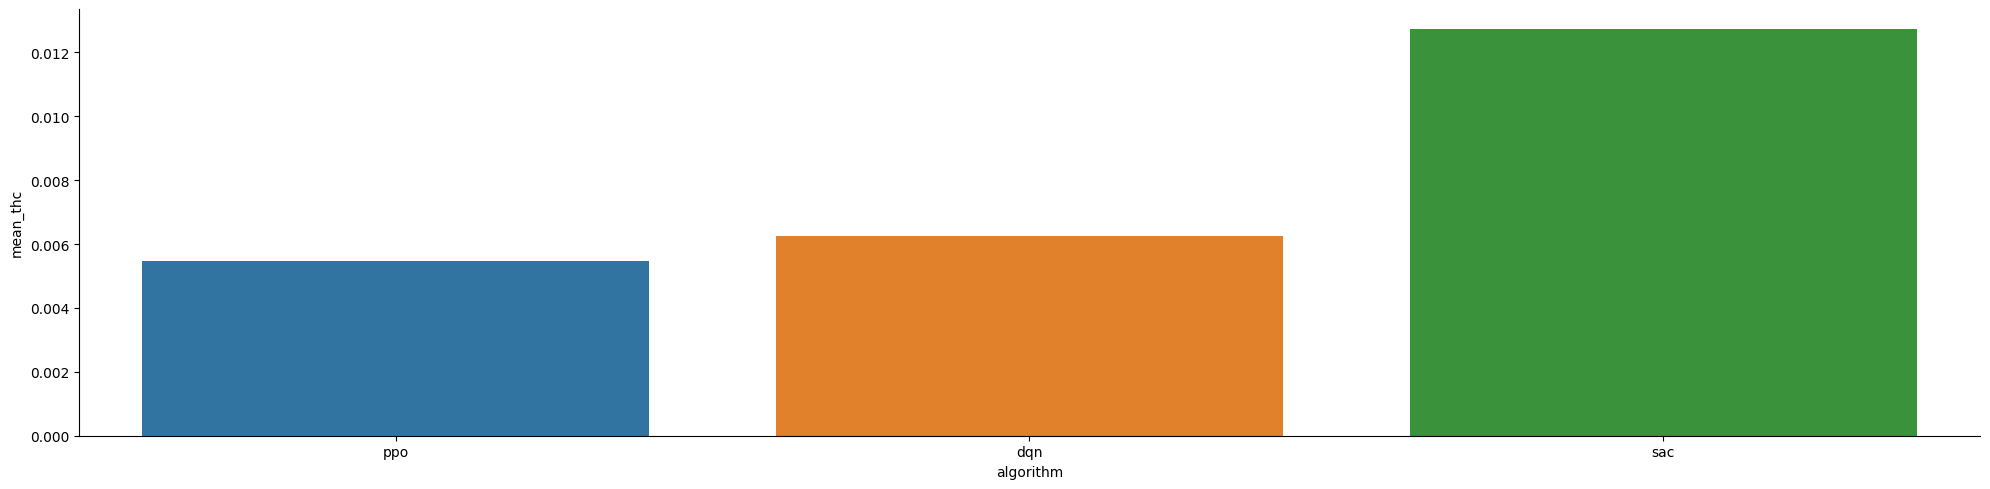

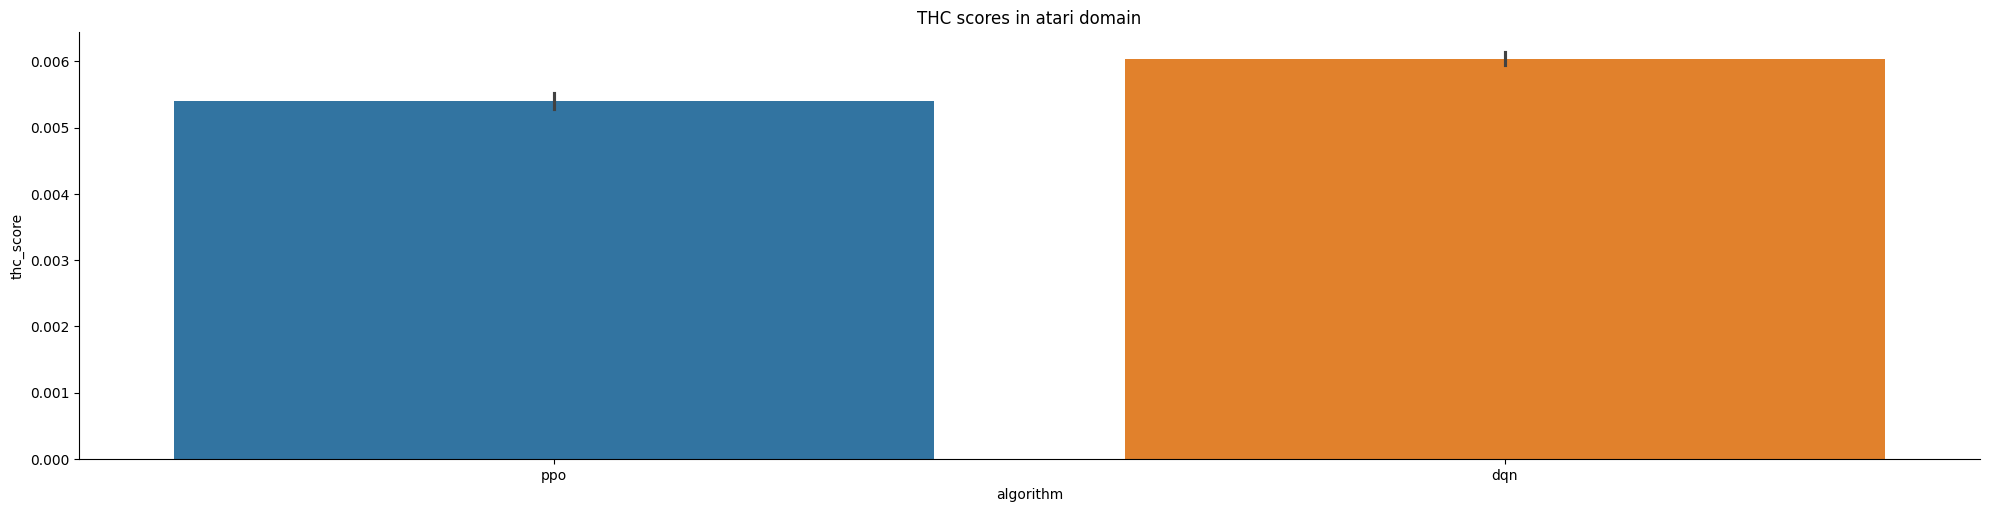

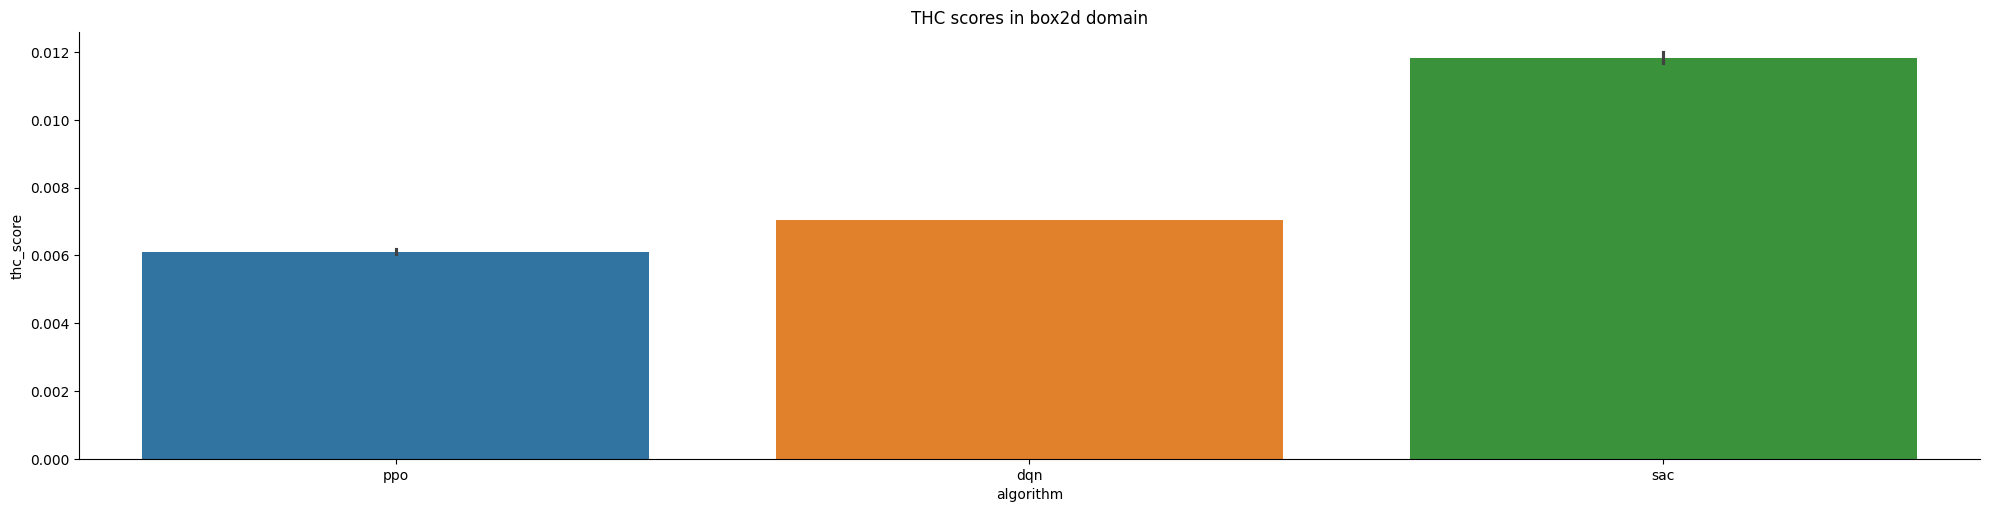

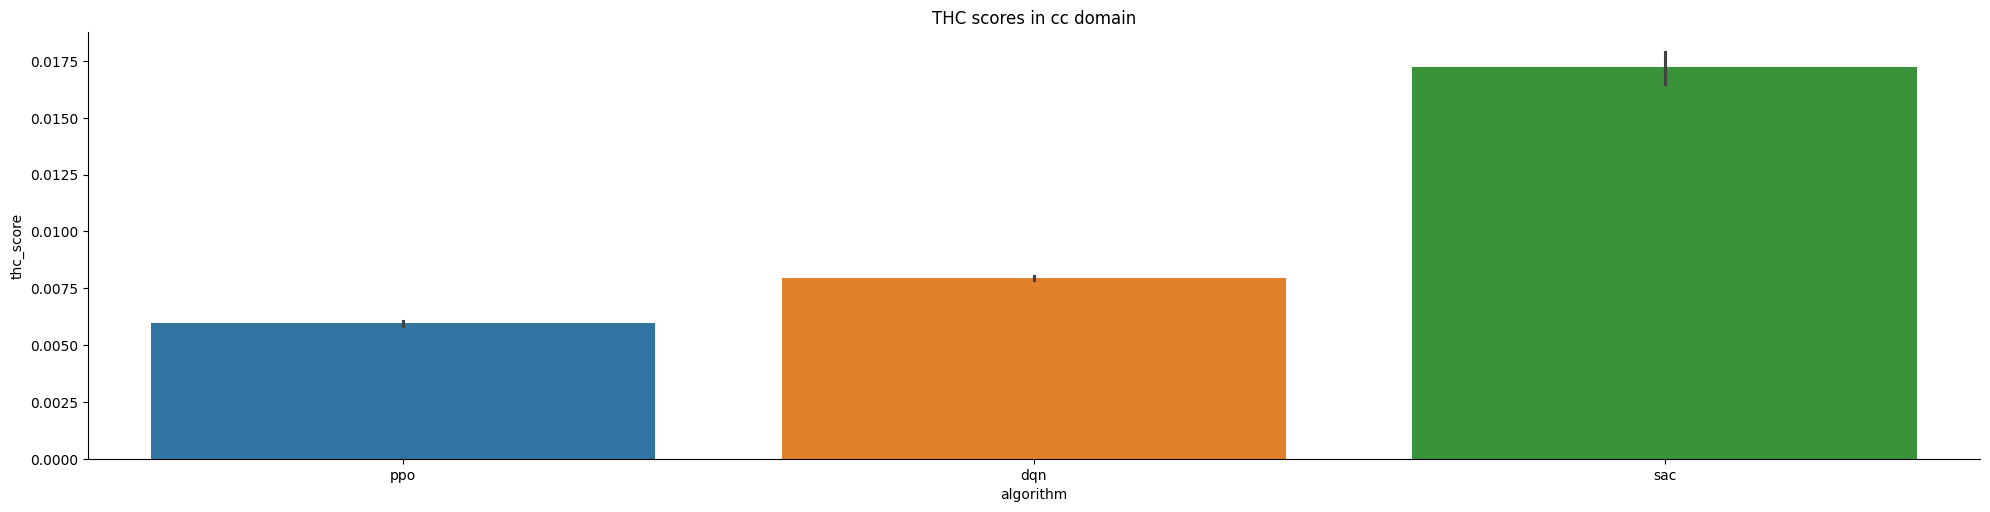

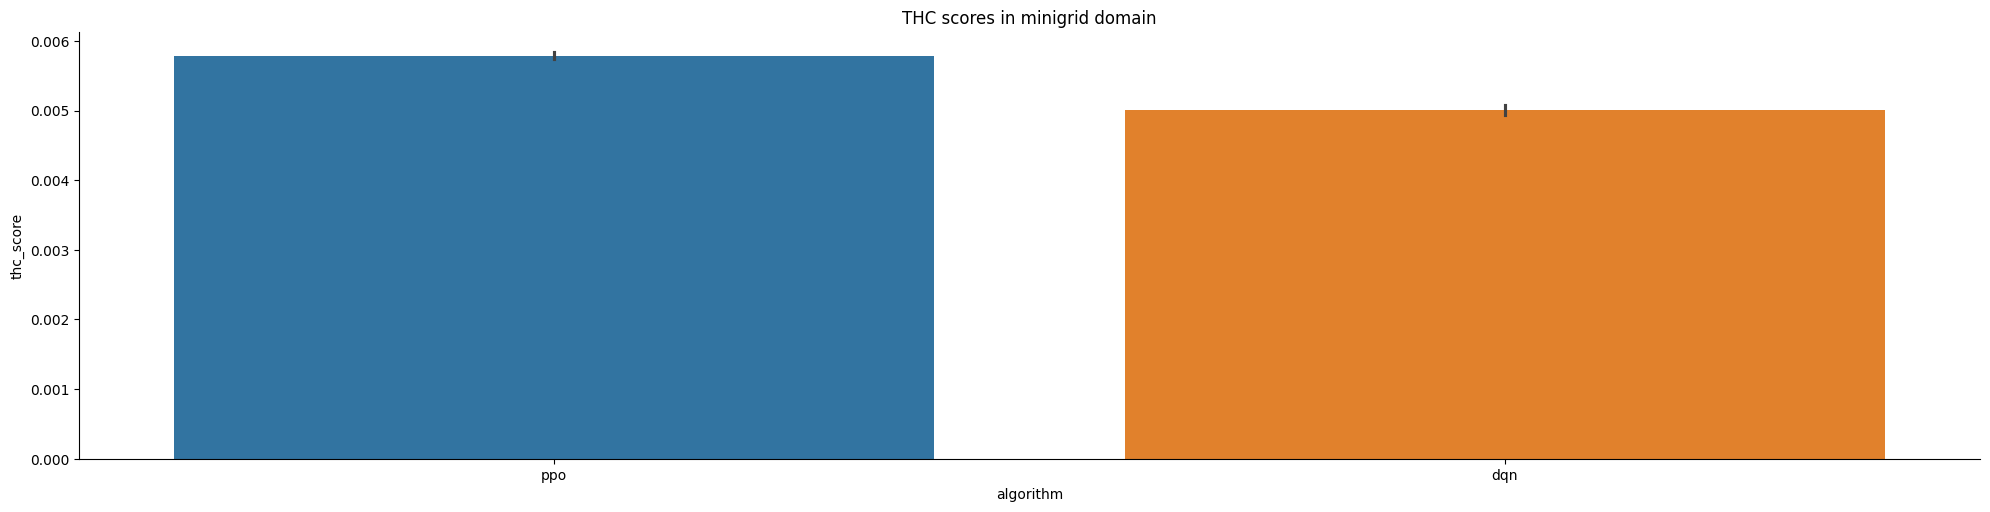

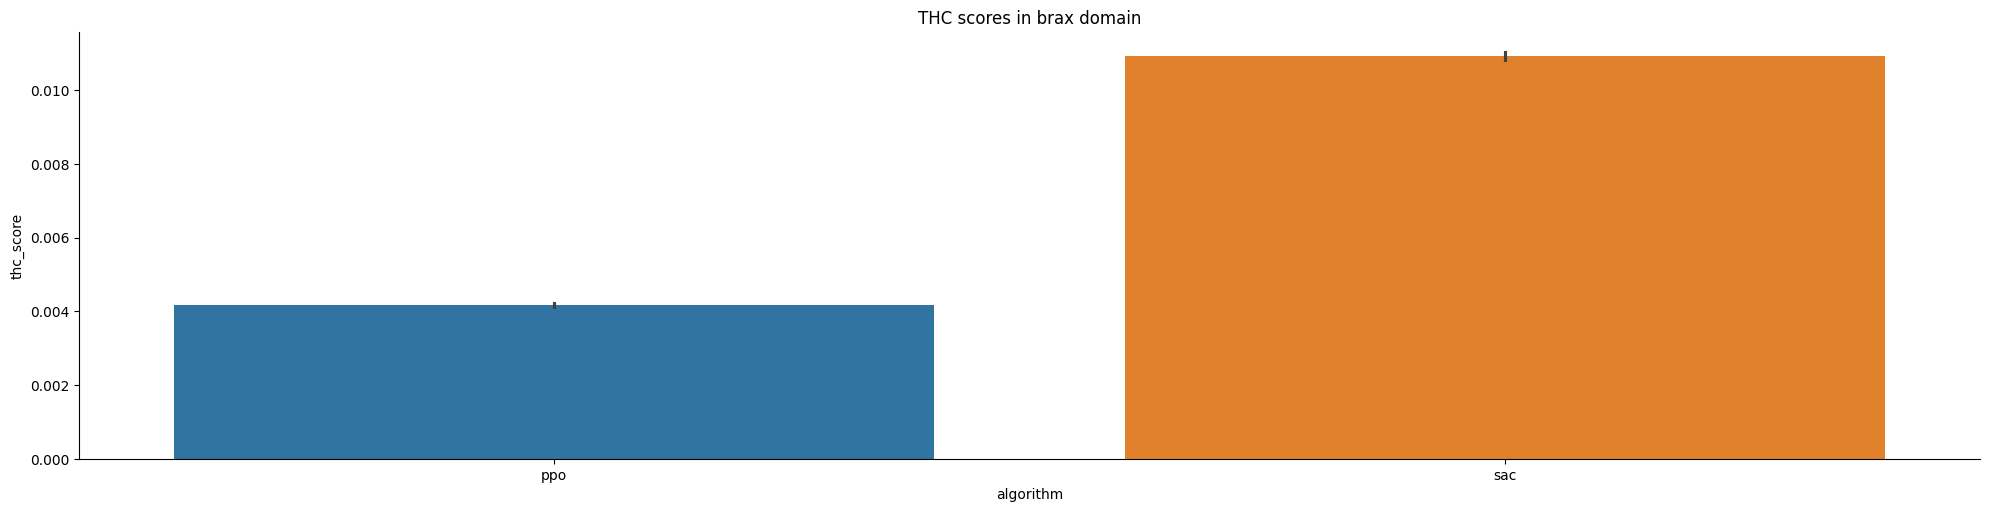

In [40]:
# THC metric
ranks = []
config_ids = []
environments = []
algorithms = []
for env in envs:
    for algo in algos:
        subset = data[data["algorithm"]==algo]
        env_subset = subset[subset["env_name"]==env]
        if len(env_subset) == 0:
            continue
        mu = env_subset.groupby("config_id")["last_performance"].mean()
        sigma = env_subset.groupby("config_id")["last_performance"].std(ddof=0)
        
        def binary_search_upper(arr, target):
            low, high = 0, len(arr)
            while low < high:
                mid = (low + high) // 2
                if arr[mid] > target:
                    high = mid
                else:
                    low = mid + 1
            return low - 1

        def binary_search_lower(arr, target):
            low, high = 0, len(arr)
            while low < high:
                mid = (low + high) // 2
                if arr[mid] < target:
                    low = mid + 1
                else:
                    high = mid
            return low

        r_prime = np.argsort(mu + sigma)[::-1]  # Descending order (higher is better)
        mu_prime = mu.iloc[r_prime]
        sigma_prime = sigma.iloc[r_prime]
        lower_bounds = mu_prime - sigma_prime
        upper_bounds = mu_prime + sigma_prime
            
        for config_id in subset["config_id"].unique():
            upper_bound_j = mu[config_id] + sigma[config_id]
            u = binary_search_upper(lower_bounds, upper_bound_j)

            lower_bound_j = mu[config_id] - sigma[config_id]
            l = binary_search_lower(upper_bounds, lower_bound_j)
            config_ids.append(config_id)
            ranks.append((u + l) / 2.0)
            environments.append(env)
            algorithms.append(algo)

thc_data = pd.DataFrame({
    "env_name": environments,
    "algorithm": algorithms,
    "config_id": config_ids,
    "thc_rank": ranks
})
thc_data["ptp"] = thc_data.groupby(["env_name", "algorithm"])["thc_rank"].transform(lambda x: x.max() - x.min())
thc_data["normed_ptp"] = thc_data["ptp"] / thc_data.groupby(["env_name", "algorithm"])["thc_rank"].transform("sum")
thc_data["thc_score"] = thc_data.groupby(["env_name", "algorithm"])["normed_ptp"].transform("mean")
thc_data["mean_thc"] = thc_data.groupby(["algorithm"])["thc_score"].transform("mean")
sns.catplot(data=thc_data, x="algorithm", y="mean_thc", hue="algorithm", kind="bar", aspect=4)
for domain in domains:
    domain_thc = thc_data[thc_data["env_name"].str.contains(domain)]
    sns.catplot(data=domain_thc, x="algorithm", y="thc_score", hue="algorithm", kind="bar", aspect=4)
    plt.title(f"THC scores in {domain} domain")